正在读取全市场数据，并预处理财务成长数据，请稍候...
正在计算财报净利润 YoY...
正在过滤主板数据...
开始按月执行 GARP(同比增长>10%) 轮动策略模拟...

✅ GARP策略交易明细已成功导出至: F:\self_quant\data\data\GARP策略交易明细.xlsx
💰 初始本金: 50,000.00 元
💰 GARP策略最终总资产: 330,590.77 元
📈 策略总收益率: 561.18%


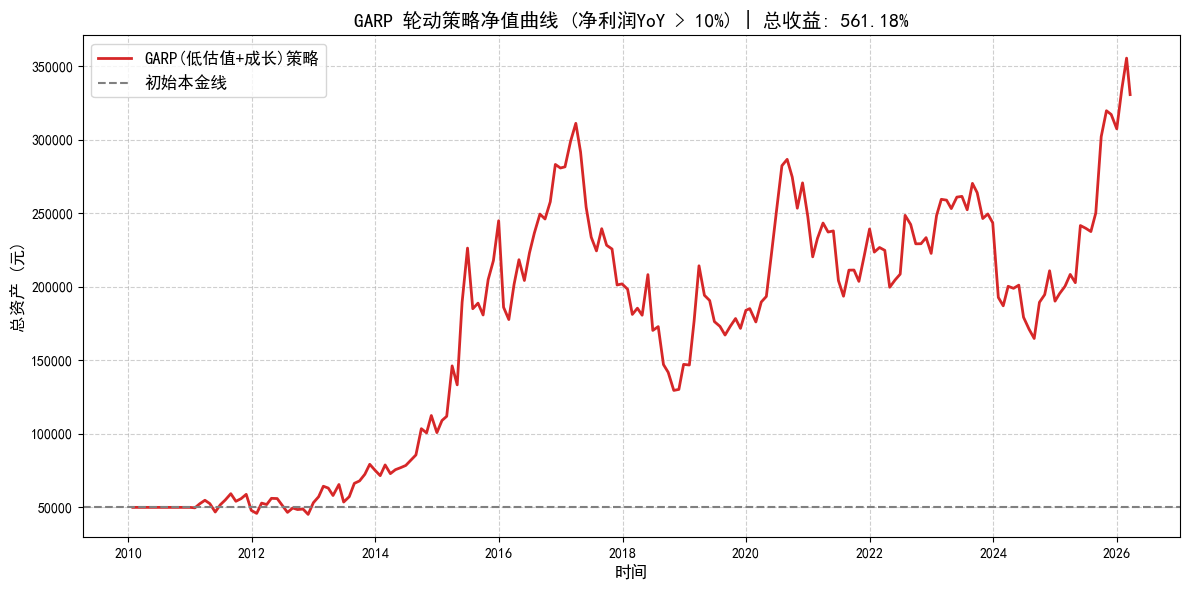

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\data\data\GARP策略交易明细.xlsx"

INITIAL_CASH = 50000.0  # 初始本金 5万元
TARGET_STOCK_NUM = 3   # 目标持仓 10 只
GROWTH_THRESHOLD = 0.1  # 净利润同比增长率阈值 (10%)

print("正在读取全市场数据，并预处理财务成长数据，请稍候...")
# 用 parquet 读取，几百万行数据通常只需几秒钟
df = pd.read_parquet(FILE_PATH)

# 确保必要的日期字段是 datetime 格式
df['date'] = pd.to_datetime(df['date'])
df['实际披露日'] = pd.to_datetime(df['实际披露日'])

# ==========================================
# 第二步：预计算净值同比(YoY)增长率 (GARP 核心)
# ==========================================
# 优化：我们在全大表上直接计算 YoY，确保回测速度
# 原理：我们提取唯一的财报序列，计算 YoY，再合并回大表
print("正在计算财报净利润 YoY...")
# 提取非空财报披露点
fund_df = df[df['实际披露日'].notna()].drop_duplicates(subset=['code', '实际披露日']).copy()
fund_df.sort_values(by=['code', '实际披露日'], inplace=True)

# 计算 YoY (同比增长)。假设财报连续，periods=4 对应去年同期（季度）。
fund_df['净利润YoY'] = fund_df.groupby('code')['净利润'].pct_change(periods=4)

# 将计算好的增长率合并回主大表 (daily data)
# 注意：主大表 date 这一天，我们使用的是通过'实际披露日'带过来的最近一期 YoY。
# 因 parquet 合并时已保证此对应关系，直接使用 df 即可，NaN 代表 YoY 计算不足4季或无去年数据。
df = pd.merge(df, fund_df[['code', '实际披露日', '净利润YoY']], on=['code', '实际披露日'], how='left')

# NaN 处理：在每日数据上，YoY可能由于缺失 NaN。
# 我们按照 code 分组，时间正序，将 NaN 填充（ffill），
# 代表在下一份报表（带新YoY）出来前，一直使用这一份的 Yo Y数据。
df.sort_values(by=['code', 'date'], inplace=True)

df['净利润YoY'] = df.groupby('code')['净利润YoY'].ffill()

# ==========================================
# 第三步：继续执行原本的策略流程 (过滤与排序)
# ==========================================
# 过滤沪深主板股票 (上交所 60 开头，深交所 00 开头)
print("正在过滤主板数据...")
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

# 提取每个月的最后一个交易日作为调仓日
df['year_month'] = df['date'].dt.to_period('M')
trade_dates = df.groupby('year_month')['date'].max().sort_values().tolist()

# ==========================================
# 第四步：定义交易费率计算函数 (原本逻辑)
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    # 1. 佣金 (最低5元)
    commission = max(5.0, amount * 0.00025)
    # 2. 过户费
    transfer_fee = amount * 0.00001
    # 3. 印花税 (仅卖出收取)
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0

    total_fee = commission + transfer_fee + stamp_duty
    return total_fee, amount

# ==========================================
# 第五步：账户类与回测主引擎 (升级版选股逻辑)
# ==========================================
class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}  # dict, {code: {'volume': 股数, 'price': 最新价}}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_date, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            price = current_prices_dict.get(code, pos['price'])
            self.positions[code]['price'] = price
            stock_value += pos['volume'] * price
        return self.cash + stock_value

account = Account(INITIAL_CASH)

print(f"开始按月执行 GARP(同比增长>{GROWTH_THRESHOLD:.0%}) 轮动策略模拟...")

for date in trade_dates:
    daily_data = df[df['date'] == date].set_index('code')
    current_prices = daily_data['close'].to_dict()

    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    # 记录资产
    current_asset = account.get_total_asset(date, current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- 选股逻辑 ----------------
    # [新增核心]：在原本安全过滤基础上，增加 净利润YoY > 0.1 门槛
    valid_pool = daily_data[
        (daily_data['tradestatus'] == 1) &
        (daily_data['isST'] == 0) &
        (daily_data['peTTM'] > 0) &
        (daily_data['净利润YoY'] > GROWTH_THRESHOLD) # 此处 NaN 自动剔除
    ].copy()

    target_codes = []
    if len(valid_pool) >= 50:
        # 下述逻辑不变
        smallest_50 = valid_pool.sort_values(by='流通市值', ascending=True).head(50).copy()
        smallest_50['pe_rank'] = smallest_50['peTTM'].rank()
        smallest_50['pb_rank'] = smallest_50['pbMRQ'].rank()
        smallest_50['score'] = smallest_50['pe_rank'] + smallest_50['pb_rank']
        target_codes = smallest_50.sort_values(by='score').head(TARGET_STOCK_NUM).index.tolist()

    # ---------------- 卖出逻辑 (逻辑不变) ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            if is_trading and pct_chg > -9.8:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']

                fee, amount = calculate_fees('sell', sell_price, sell_vol)

                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'YoY:{daily_data.loc[code, "净利润YoY"]:.2%}'
                })
            elif pct_chg <= -9.8:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(跌停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'跌幅 {pct_chg:.2f}% 封死跌停'
                })

    # ---------------- 买入逻辑 (逻辑不变) ----------------
    current_asset = account.get_total_asset(date, current_prices)
    stocks_to_buy = [code for code in target_codes if code not in account.positions]

    if len(stocks_to_buy) > 0:
        target_cash_per_stock = account.cash / len(stocks_to_buy)

        for code in stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            is_st = st_dict.get(code, 0) == 1

            if is_trading and not is_st and pct_chg < 9.8:
                buy_price = current_prices[code]
                # 缓冲金计算整手股数
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)

                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入',
                            '成交价': buy_price, '成交股数': buy_vol,
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                            '备注': f'YoY:{valid_pool.loc[code, "净利润YoY"]:.2%}'
                        })
            elif pct_chg >= 9.8:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '买入失败(涨停)',
                    '成交价': 0, '成交股数': 0, '成交金额': 0, '交易费': 0,
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': f'涨幅 {pct_chg:.2f}% 封死涨停'
                })

# ==========================================
# 第六步：输出结果与可视化
# ==========================================
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n✅ GARP策略交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 GARP策略最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

# 绘制收益曲线对比 (如果想看旧策略线，需要保留旧策略数据，这里简化只绘制新线)
plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#d62728', linewidth=2, label='GARP(低估值+成长)策略')
plt.title(f'GARP 轮动策略净值曲线 (净利润YoY > {GROWTH_THRESHOLD:.0%}) | 总收益: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金线')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()